# Notebook 03 — Clustering Experiments

Visualise clustering results and compare algorithms.

In [1]:
import sys; sys.path.insert(0, '..')
import pickle, numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt, seaborn as sns
from scipy.sparse import load_npz
from src.evaluation import get_top_terms, cluster_size_distribution


## 1. Load Artifacts

In [2]:
DATASET = 'newsgroups'   # change to 'wikipedia' to switch

with open(f'../data/processed/{DATASET}_clean.pkl','rb') as f: corpus = pickle.load(f)
vec    = joblib.load(f'../models/tfidf_{DATASET}.pkl')
svd    = joblib.load(f'../models/svd_{DATASET}.pkl')
X      = np.load(f'../data/processed/X_reduced_{DATASET}.npy')
X_tf   = load_npz(f'../data/processed/X_tfidf_{DATASET}.npz')
metrics = pd.read_csv(f'../outputs/reports/clustering_metrics_{DATASET}.csv')
print(f"Dataset: {DATASET} | Docs: {X.shape[0]:,} | Features: {X.shape[1]}")


Dataset: newsgroups | Docs: 18,195 | Features: 100


## 2. Elbow Curve (K-Means)

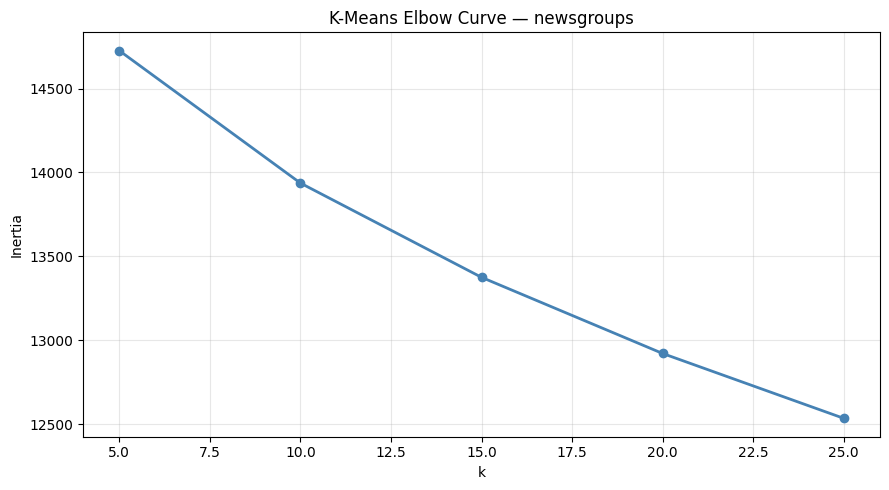

In [3]:
km_metrics = metrics[metrics['algorithm']=='kmeans'].sort_values('k')
inertias   = [joblib.load(f'../models/kmeans_{DATASET}_k{k}.pkl').inertia_
              for k in km_metrics['k']]
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(km_metrics['k'], inertias, 'o-', linewidth=2, color='steelblue')
ax.set_xlabel('k'); ax.set_ylabel('Inertia')
ax.set_title(f'K-Means Elbow Curve — {DATASET}')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 3. Silhouette Score vs. k (all algorithms)

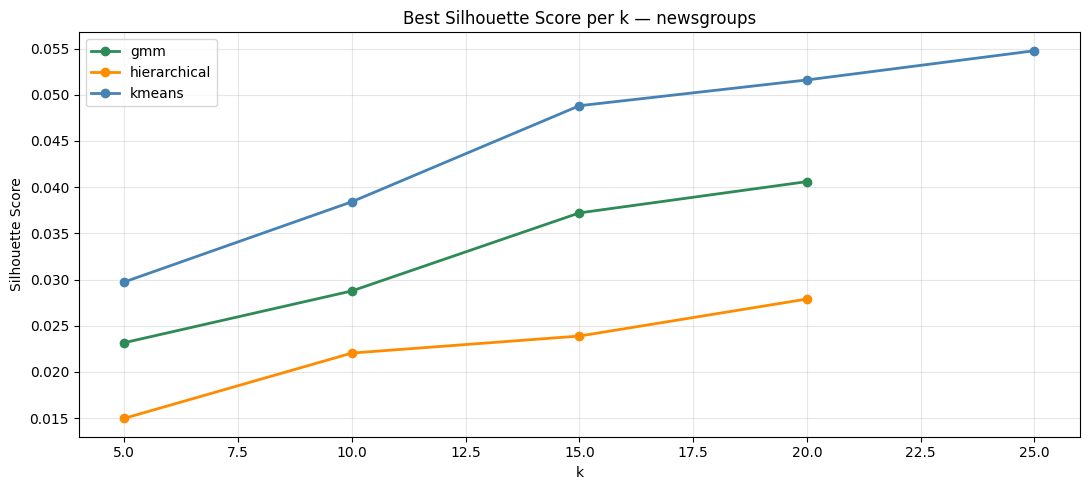

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
colors = {'kmeans':'steelblue','hierarchical':'darkorange','gmm':'seagreen'}
for algo, grp in metrics.groupby('algorithm'):
    best_per_k = grp.groupby('k')['silhouette'].max().reset_index()
    ax.plot(best_per_k['k'], best_per_k['silhouette'], 'o-',
            label=algo, color=colors.get(algo,'gray'), linewidth=2)
ax.set_xlabel('k'); ax.set_ylabel('Silhouette Score')
ax.set_title(f'Best Silhouette Score per k — {DATASET}')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 4. Best K-Means: PCA Scatter

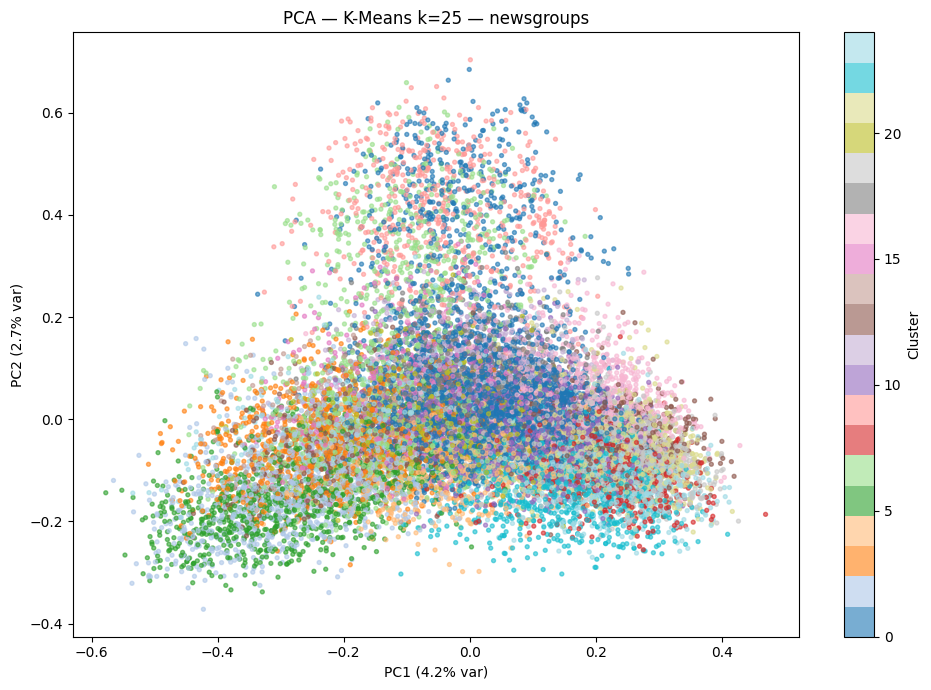

In [5]:
from sklearn.decomposition import PCA
best_k = int(metrics[metrics['algorithm']=='kmeans']['silhouette'].idxmax())
best_k = int(metrics.loc[best_k,'k'])
model  = joblib.load(f'../models/kmeans_{DATASET}_k{best_k}.pkl')
labels = model.predict(X)

pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)
var    = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(coords[:,0], coords[:,1], c=labels, cmap='tab20', s=8, alpha=0.6)
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.set_xlabel(f'PC1 ({var[0]:.1%} var)'); ax.set_ylabel(f'PC2 ({var[1]:.1%} var)')
ax.set_title(f'PCA — K-Means k={best_k} — {DATASET}')
plt.tight_layout(); plt.show()


## 5. Top Terms per Cluster (Best K-Means)

In [6]:
top_terms = get_top_terms(labels, vec, X_tf, n=10)
sizes     = cluster_size_distribution(labels)
print(f"{'Cluster':>8} {'Size':>6}  Top Terms")
print("-" * 80)
for cid in sorted(top_terms):
    terms = ", ".join(top_terms[cid][:8])
    print(f"Cluster {cid:2d}  {sizes[cid]:5d}  {terms}")


 Cluster   Size  Top Terms
--------------------------------------------------------------------------------
Cluster  0   2523  like, would, get, one, know, article, well, good
Cluster  1    454  game, espn, baseball, hockey, playoff, fan, night, last
Cluster  2   1146  people, one, would, say, religion, christian, point, thing
Cluster  3    983  gun, law, government, people, state, right, would, one
Cluster  4    511  key, clipper, chip, encryption, government, algorithm, escrow, nsa
Cluster  5    868  god, jesus, christian, christ, bible, sin, one, believe
Cluster  6    487  year, hit, player, pitcher, team, last, run, game
Cluster  7    808  doctor, one, cause, effect, patient, problem, get, people
Cluster  8    483  file, format, program, directory, window, gif, ftp, convert
Cluster  9    553  team, player, hockey, season, play, nhl, game, goal
Cluster 10   1264  use, one, power, work, monitor, chip, board, would
Cluster 11    433  bike, dod, ride, riding, motorcycle, rider, one, fr

## 6. Algorithm Comparison — Cluster Sizes

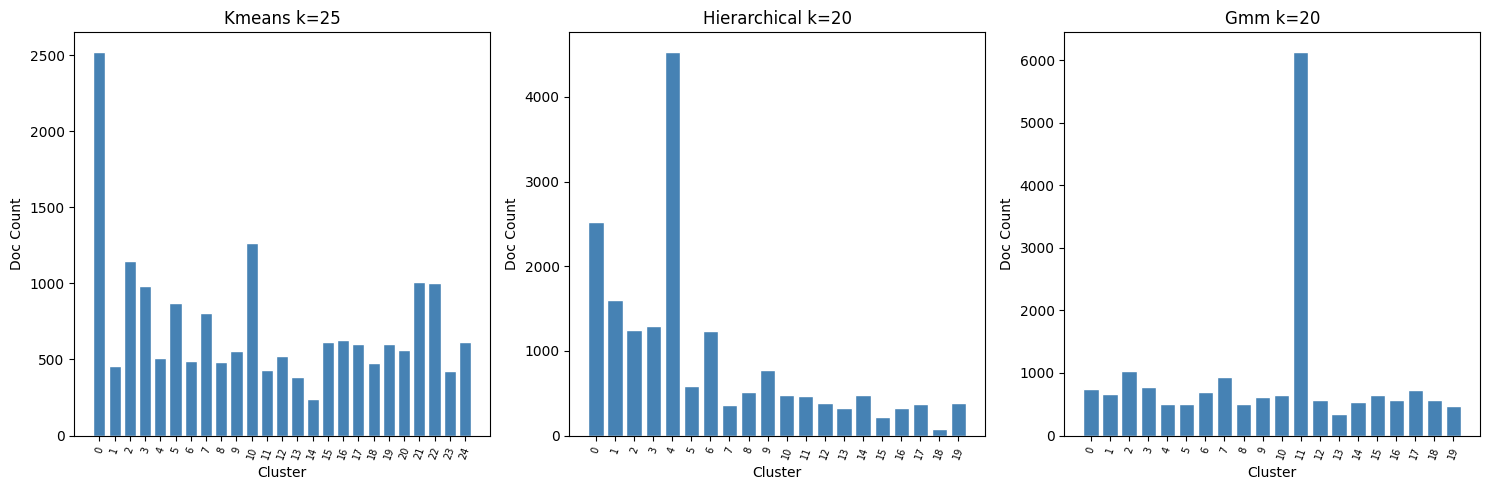

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, algo in zip(axes, ['kmeans', 'hierarchical', 'gmm']):
    best_row  = metrics[metrics['algorithm']==algo].loc[metrics[metrics['algorithm']==algo]['silhouette'].idxmax()]
    k = int(best_row['k'])
    suffix = ''
    if algo == 'hierarchical': suffix = '_ward'
    elif algo == 'gmm':        suffix = '_tied'
    model_path = f'../models/{algo}_{DATASET}_k{k}{suffix}.pkl'
    import os
    if not os.path.exists(model_path): model_path = next(iter(
        __import__('glob').glob(f'../models/{algo}_{DATASET}_k{k}*.pkl')), None)
    if model_path is None: continue
    m = joblib.load(model_path)
    lbs = m.predict(X) if hasattr(m,'predict') else m.labels_
    unique, counts = np.unique(lbs, return_counts=True)
    ax.bar(unique.astype(str), counts, color='steelblue', edgecolor='white')
    ax.set_title(f'{algo.title()} k={k}')
    ax.set_xlabel('Cluster'); ax.set_ylabel('Doc Count')
    ax.tick_params(axis='x', rotation=70, labelsize=7)
plt.tight_layout(); plt.show()
